<a href="https://colab.research.google.com/github/YABIGAIL23/Simulaci-n-II/blob/main/Clase_10_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Euler-Maruyama

In [ ]:
import numpy as np

def f(delta, T):
  sigma = np.sqrt(delta)
  t = 0
  x = 1.0
  s = 0.0
  while t < T:
    w = np.random.normal(0, sigma) #media 0 y desviación sigma
    #x - 1 no-negativo
    sqrt_term = np.sqrt(max(0, x - 1))
    s = s + w
    x = x + delta + 2 * sqrt_term * w
    #Avance del paso del tiempo
    t = t + delta
    #Cálculo del valor de control Z y el error cuadrático final
    z = 1 + s**2
  return (x - z)**2

In [ ]:
#Ejemplo
delta_t = 0.1
tiempo_final = 0.2
resultado = f(delta_t, tiempo_final)
print(f"Error cuadrático de la simulación: {resultado}")

Error cuadrático de la simulación: 0.1526039844820473


In [ ]:
#Ejemplo
delta_t = 0.05
tiempo_final = 0.2
print("Error cuadrático de la simulación")
print("__________________________________")

print(f"delta=0.01:   {f(0.01, tiempo_final)}")
print(f"delta=0.05:   {f(0.05, tiempo_final)}")
print(f"delta=0.001:  {f(0.001, tiempo_final)}")
print(f"delta=0.005:  {f(0.005, tiempo_final)}")



Error cuadrático de la simulación
__________________________________
delta=0.01:   0.22616325471603568
delta=0.05:   0.018259476773211072
delta=0.001:  2.40958649089151e-06
delta=0.005:  0.0002566397490681724


Lo de arriba no funcionó

In [ ]:
import math
import random
from numba import jit

@jit(nopython=True)
def f(T, delta, mu, sigma_vol):#parámetro de volatilidad (ej. 0.2)
    t = 0
    x = 10  #X_0
    S = 0

    while t < T:
        #Paso del Movimiento Browniano
        dW = math.sqrt(delta) * random.gauss(0, 1)
        x = x + mu * x * delta + sigma_vol * x * dW
        t = t + delta
        S = S + dW
    z = 10 * math.exp((mu - (sigma_vol**2) / 2) * T + sigma_vol * S)
    return (x - z) ** 2

Estimado  0.0011269425947144783


In [ ]:
#Ejemplo
delta_t = 0.001
tiempo_final = 0.2
mu = 0.5
sigma_vol = 0.2
resultado = f(tiempo_final, delta_t, mu, sigma_vol)
print(f"Estimado  {resultado}")

Estimado  1.0935064624644589e-05


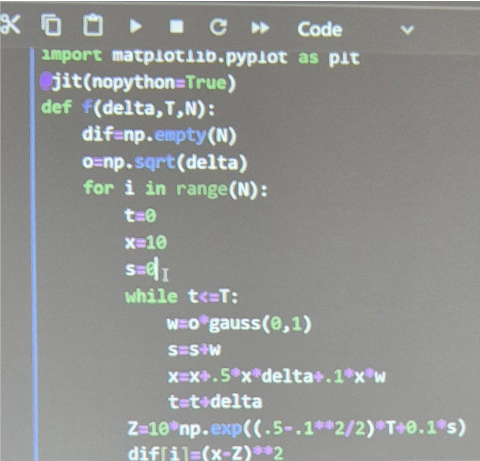

In [ ]:
def f(delta, T, N):
  dif=np.empty(N)
  o=np.sqrt(delta)

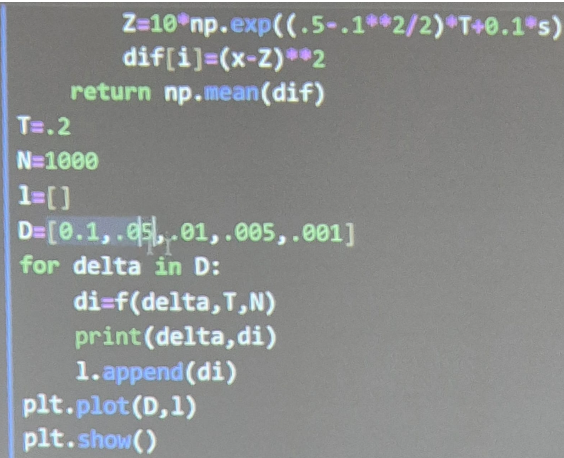